In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
emmarex_plantdisease_path = kagglehub.dataset_download('emmarex/plantdisease')

print('Data source import complete.')


In [ ]:
# Cell 1: Imports & configuration
import os, random, shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, Activation, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Paths (adjust if needed)
ORIG_DATASET = "/kaggle/input/plantdisease/PlantVillage"  # original dataset with 15 class subfolders
SPLIT_BASE = "/kaggle/working/split_dataset"
TRAIN_DIR = os.path.join(SPLIT_BASE, "train")
TEST_DIR  = os.path.join(SPLIT_BASE, "test")

# Where to save best weights
BEST_WEIGHTS_PATH = "/kaggle/working/best_model.weights.h5"

print("Configured paths:")
print("ORIG_DATASET:", ORIG_DATASET)
print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR:", TEST_DIR)
print("BEST_WEIGHTS_PATH:", BEST_WEIGHTS_PATH)


2025-09-28 14:36:06.771789: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759070167.145790      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759070167.252650      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Configured paths:
ORIG_DATASET: /kaggle/input/plantdisease/PlantVillage
TRAIN_DIR: /kaggle/working/split_dataset/train
TEST_DIR: /kaggle/working/split_dataset/test
BEST_WEIGHTS_PATH: /kaggle/working/best_model.weights.h5


In [ ]:
# Cell 2: Create train/test split (copies images to working directory)
# If split dirs already exist, we skip copying to avoid re-copying in repeated runs.
if not os.path.exists(TRAIN_DIR) or not os.path.exists(TEST_DIR):
    os.makedirs(TRAIN_DIR, exist_ok=True)
    os.makedirs(TEST_DIR, exist_ok=True)

    test_split = 0.1  # 10% into test; change if you want different ratio

    for class_name in sorted(os.listdir(ORIG_DATASET)):
        class_path = os.path.join(ORIG_DATASET, class_name)
        if not os.path.isdir(class_path):
            continue

        imgs = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
        random.shuffle(imgs)

        split_idx = int(len(imgs) * (1 - test_split))
        train_imgs = imgs[:split_idx]
        test_imgs  = imgs[split_idx:]

        os.makedirs(os.path.join(TRAIN_DIR, class_name), exist_ok=True)
        os.makedirs(os.path.join(TEST_DIR, class_name), exist_ok=True)

        for img in train_imgs:
            src = os.path.join(class_path, img)
            dst = os.path.join(TRAIN_DIR, class_name, img)
            if not os.path.exists(dst):
                shutil.copy(src, dst)

        for img in test_imgs:
            src = os.path.join(class_path, img)
            dst = os.path.join(TEST_DIR, class_name, img)
            if not os.path.exists(dst):
                shutil.copy(src, dst)

    print("Train/Test split created.")
else:
    print("Split dataset folders already exist. Skipping copy.")


Train/Test split created.


In [ ]:
# Cell 3: Data generators
BATCH_SIZE = 32
IMG_SIZE = (227, 227)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=50,
    width_shift_range=0.4,
    height_shift_range=0.4,
    shear_range=0.4,
    zoom_range=0.4,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2  # 80% train / 20% val from TRAIN_DIR
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

validation_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED
)

# Test generator (completely unseen)
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # important for consistent metrics & mapping indices
)

num_train = train_generator.samples
num_val = validation_generator.samples
num_test = test_generator.samples
num_classes = len(train_generator.class_indices)

print(f"Train: {num_train}, Val: {num_val}, Test: {num_test}, Classes: {num_classes}")


Found 14859 images belonging to 15 classes.
Found 3709 images belonging to 15 classes.
Found 2070 images belonging to 15 classes.
Train: 14859, Val: 3709, Test: 2070, Classes: 15


In [ ]:
# Cell 4: Build model (AlexNet-style with BatchNorm, adapted for 15 classes)
model = Sequential([
    Conv2D(96, kernel_size=(11,11), strides=(4,4), input_shape=(227,227,3)),
    BatchNormalization(), Activation('relu'),
    MaxPool2D(pool_size=(3,3), strides=(2,2)),

    Conv2D(256, kernel_size=(5,5), padding='same'),
    BatchNormalization(), Activation('relu'),
    MaxPool2D(pool_size=(3,3), strides=(2,2)),

    Conv2D(384, kernel_size=(3,3), padding='same'),
    BatchNormalization(), Activation('relu'),
    Conv2D(384, kernel_size=(3,3), padding='same'),
    BatchNormalization(), Activation('relu'),
    Conv2D(256, kernel_size=(3,3), padding='same'),
    BatchNormalization(), Activation('relu'),
    MaxPool2D(pool_size=(3,3), strides=(2,2)),

    Flatten(),
    Dense(4096), BatchNormalization(), Activation('relu'), Dropout(0.5),
    Dense(4096), BatchNormalization(), Activation('relu'), Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# Compile model
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1759070275.945052      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759070275.945726      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 55, 55, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 55, 55, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 27, 27, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 27, 27, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 13, 13, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 13, 13, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 13, 13, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 13, 13, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 13, 13, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 4096)           │        16,384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 4096)           │             

 Total params: 58,381,071 (222.71 MB)

 Trainable params: 58,361,935 (222.63 MB)

 Non-trainable params: 19,136 (74.75 KB)

In [ ]:
# Cell 5: Callbacks
earlystop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=False,  # we'll load weights from checkpoint file
    verbose=1
)

checkpoint = ModelCheckpoint(
    BEST_WEIGHTS_PATH,
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    save_weights_only=True,
    mode='max'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1,
    min_lr=1e-7
)

callbacks = [earlystop, checkpoint, reduce_lr]


In [ ]:
# Cell 6: Training

history = model.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator,
    callbacks=callbacks
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1759070285.614091     121 service.cc:148] XLA service 0x7f690000a160 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1759070285.615696     121 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1759070285.615718     121 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1759070286.423860     121 cuda_dnn.cc:529] Loaded cuDNN version 90300


  2/465 ━━━━━━━━━━━━━━━━━━━━ 35s 76ms/step - accuracy: 0.0547 - loss: 3.5347   

I0000 00:00:1759070294.544541     121 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.3928 - loss: 2.1027
Epoch 1: val_accuracy improved from -inf to 0.15368, saving model to /kaggle/working/best_model.weights.h5
465/465 ━━━━━━━━━━━━━━━━━━━━ 229s 459ms/step - accuracy: 0.3930 - loss: 2.1019 - val_accuracy: 0.1537 - val_loss: 7.5169 - learning_rate: 1.0000e-04
Epoch 2/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.6135 - loss: 1.2206
Epoch 2: val_accuracy improved from 0.15368 to 0.46266, saving model to /kaggle/working/best_model.weights.h5
465/465 ━━━━━━━━━━━━━━━━━━━━ 206s 444ms/step - accuracy: 0.6136 - loss: 1.2205 - val_accuracy: 0.4627 - val_loss: 2.8616 - learning_rate: 1.0000e-04
Epoch 3/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.7070 - loss: 0.9229
Epoch 3: val_accuracy improved from 0.46266 to 0.59827, saving model to /kaggle/working/best_model.weights.h5
465/465 ━━━━━━━━━━━━━━━━━━━━ 205s 440ms/step - accuracy: 0.7070 - loss: 0.9229 - val_accuracy: 0.5983 - val_loss: 1.4126 -

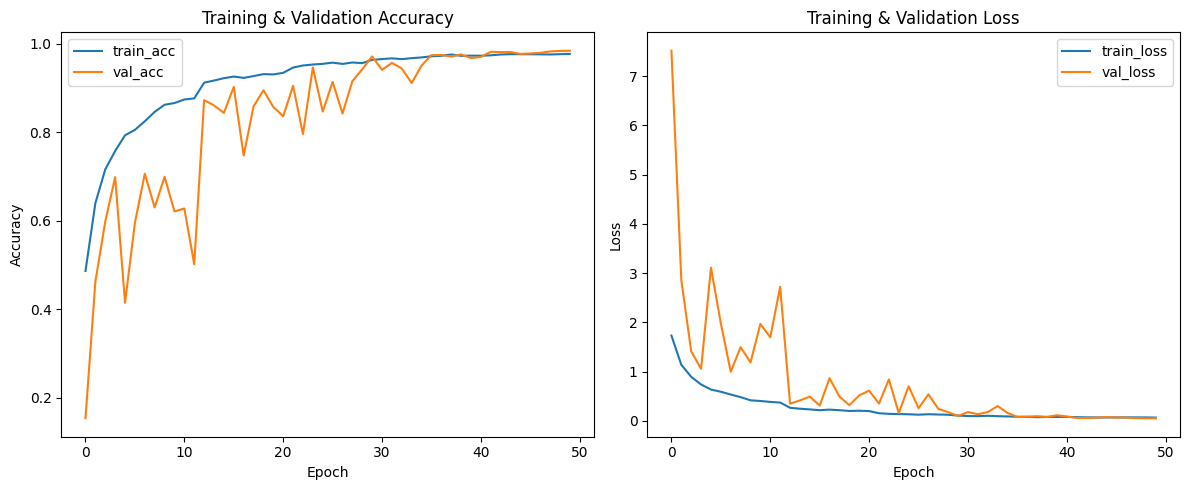

Saved training_curves.png to /kaggle/working/


In [ ]:
# Cell 7: Plot training curves
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training & Validation Accuracy')

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Validation Loss')

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()

print("Saved training_curves.png to /kaggle/working/")


In [ ]:
# Cell 8: Load best weights and evaluate on the unseen test set
if os.path.exists(BEST_WEIGHTS_PATH):
    model.load_weights(BEST_WEIGHTS_PATH)
    print("Best weights loaded from", BEST_WEIGHTS_PATH)
else:
    print("Best weights not found at", BEST_WEIGHTS_PATH, "- using current model weights.")

test_loss, test_acc = model.evaluate(test_generator)
print(f"\nTest Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")


✅ Best weights loaded from /kaggle/working/best_model.weights.h5
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.9851 - loss: 0.0424

Test Loss: 0.1221, Test Accuracy: 0.9797


65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step

--- CLASSIFICATION REPORT (Test set) ---

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot     0.9802    0.9900    0.9851       100
                     Pepper__bell___healthy     0.9867    1.0000    0.9933       148
                      Potato___Early_blight     0.9346    1.0000    0.9662       100
                       Potato___Late_blight     0.9238    0.9700    0.9463       100
                           Potato___healthy     0.8889    1.0000    0.9412        16
                      Tomato_Bacterial_spot     0.9953    0.9953    0.9953       213
                        Tomato_Early_blight     0.9802    0.9900    0.9851       100
                         Tomato_Late_blight     0.9945    0.9424    0.9677       191
                           Tomato_Leaf_Mold     1.0000    1.0000    1.0000        96
                  Tomato_Septoria_leaf_spot     0.9888    0.9888  

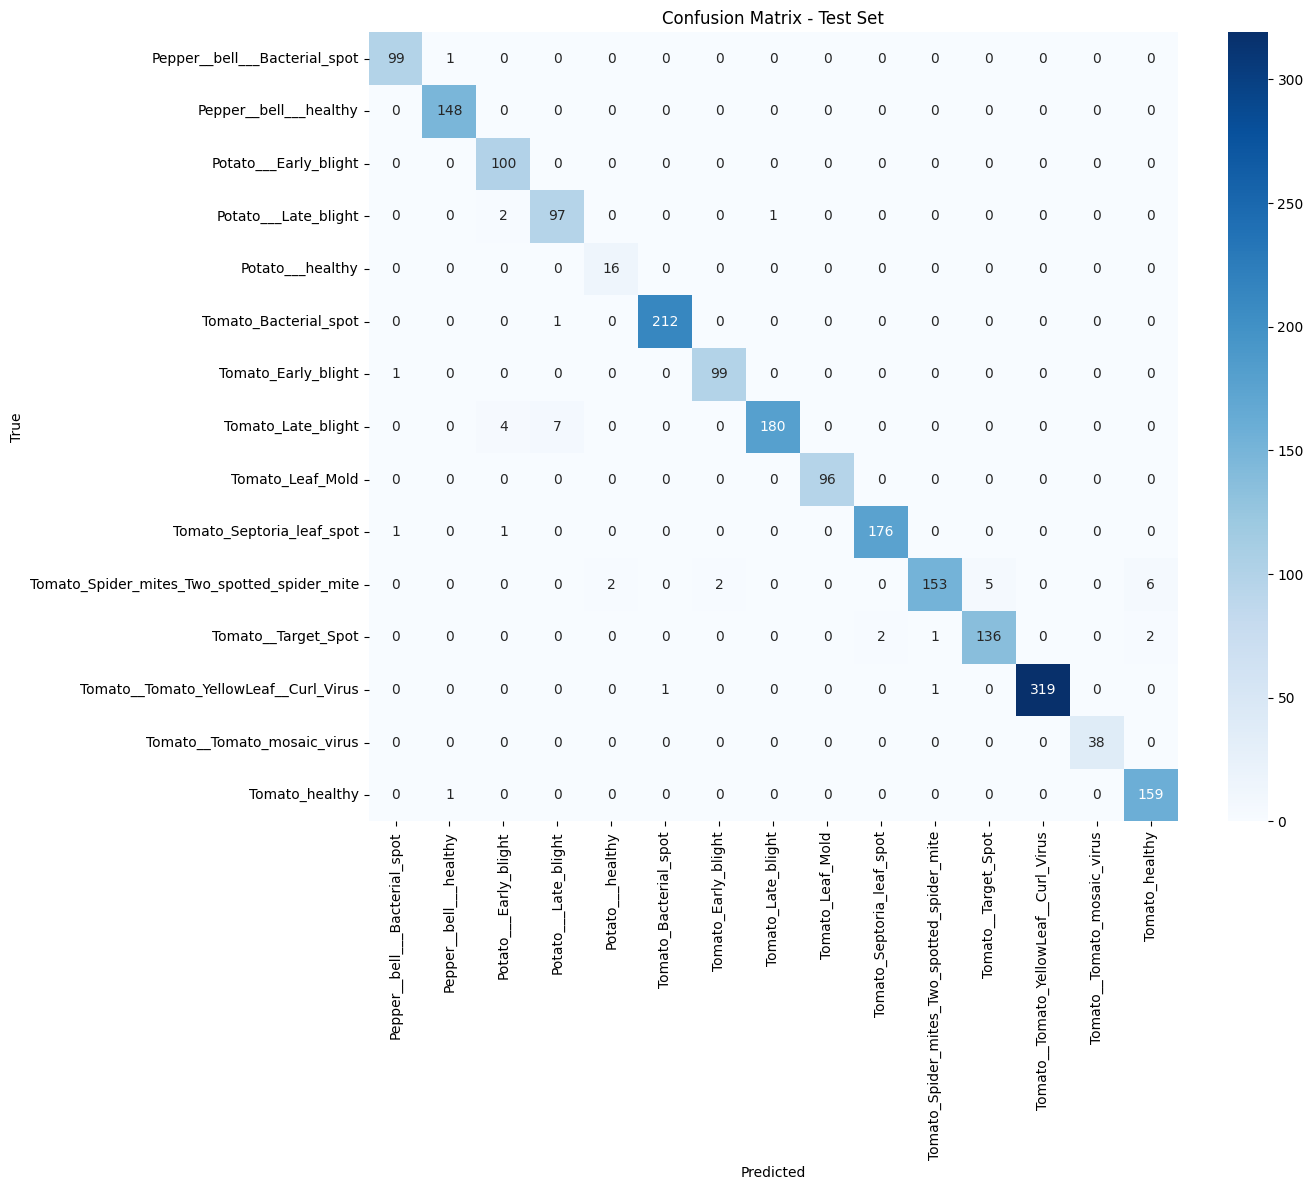

Saved confusion_matrix.png to /kaggle/working/


In [ ]:
# Cell 9: Predictions and classification metrics
y_true = test_generator.classes
class_indices = test_generator.class_indices
# Make a deterministic list of class names sorted by index
# test_generator.class_indices maps name->index; invert it
idx2class = {v:k for k,v in class_indices.items()}
class_names = [idx2class[i] for i in range(len(idx2class))]

# Predict (this will iterate over test_generator)
preds = model.predict(test_generator, verbose=1)
y_pred = np.argmax(preds, axis=1)

# Classification report
print("\n--- CLASSIFICATION REPORT (Test set) ---\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14,12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Test Set")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()

print("Saved confusion_matrix.png to /kaggle/working/")


In [ ]:
# Cell 10: Save classification report to a file for download
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
with open('/kaggle/working/classification_report.txt', 'w') as f:
    f.write(report)

print("Saved classification_report.txt to /kaggle/working/")


Saved classification_report.txt to /kaggle/working/


In [ ]:
#export it to google drive

from google.colab import auth
from googleapiclient.discovery import build
from googleapiclient.http import MediaFileUpload


auth.authenticate_user()

drive_service = build('drive', 'v3')

file_path = '/kaggle/working/best_model.weights.h5'
file_name = 'alexnet_best_model.weights.h5'

file_metadata = {
    'name': file_name

}

media = MediaFileUpload(file_path, mimetype='application/octet-stream', resumable=True)

request = drive_service.files().create(
    body=file_metadata,
    media_body=media,
    fields='id'
)

response = None
while response is None:
  status, response = request.next_chunk()
  if status:
    print(f"Uploaded {int(status.progress() * 100)}%")

print(f"File '{file_name}' uploaded successfully with File ID: {response.get('id')}")

Uploaded 14%
Uploaded 29%
Uploaded 44%
Uploaded 59%
Uploaded 74%
Uploaded 89%
File 'alexnet_best_model.weights.h5' uploaded successfully with File ID: 1uNjDBuXFLsUWFyRK4AwBWSHhK4OBn5mW
